# MSCFE 690: Capstone Project
### Student Group: 11186

Idea & algorithm explorations continue from ```capstone_draft1_RB.ipynb```. In this notebook, I just wanted to try a few different ways we could treat the data, build a model, and use the model inference to make investment decisions. Some of the highlights are as follows:

### Section 1: Data Preparation

#### 1.1. Data Fetching, Cleaning & Stationary Test
- Factor returns and potentially relevant macroeconomic variables were fetched.
- ADF test was performed.

#### 1.2. Data Aggregation
- Variables were concatenated into 1 dataframe & made stationary.

#### 1.3. Evaluation of Mutual Information
- Pairwise MI were calculated.
- Confusing results as many MI values between (stationary) macroeconomic variables & factor returns were 0.

#### 1.4. Data Discretization with Trend Scanning
- Take a step back on to the drawing board.
- Tried a new data discretization method called trend scanning from Lopez de Prado's book, so we don't have to worry about whether the data are stationary or not.
- The method labels whether a data point is part of an up-trend or down-trend.

### Section 2: Bayesian Network

#### 2.1. Dynamic BN Structure Learning
- Using the discretized (trend-labeled) training data, a DYNOTEARS model-based DAG structure was estimated.

#### 2.2. Parameter Learning
- The parameters for the estimated DAG was trained.
- The result was a series of conditional probability tables (CPTs)

#### 2.3. An Inference Example
- Tried performing inferences with the macroeconomic indicator states as evidence.
- This is where I got stuck ... How can we use the inference results (which were from discrete data) & turn them into estimates of (continuous) $\mu$ and $\Sigma$ for the next period that we can use for in a separate utility optimization module?
- I proposed a crude way of taking the most likely states for the factors (i.e., the future trends based on the inference results w/ the highest probability given the macroeconomic evidence).
- Based on that, we can calculate the estimates of $\mu$ and $\Sigma$ derived from the state (trend)-dependent mean & std dev of returns (calculated from the past training data).
- That's one way of doing this, I suppose. Needs to be discussed further with the team.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib
import yfinance as yf
import pandas_datareader as web
import causalnex
# import pgmpy

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (6,3)
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

print(f"platform:\t\t{sys.platform}")
print(f"python version:\t\t{sys.version}")
print(f"pandas version:\t\t{pd.__version__}")
print(f"numpy version:\t\t{np.__version__}")
print(f"matplotlib version:\t{matplotlib.__version__}")
print(f"yfinance version:\t{yf.__version__}")
print(f"pd-datareader version:\t{web.__version__}")
print(f"causalnex version:\t{causalnex.__version__}")
# print(f"pgmpy version:\t\t{pgmpy.__version__}")

platform:		darwin
python version:		3.10.18 (main, Jun  5 2025, 08:37:47) [Clang 14.0.6 ]
pandas version:		2.2.3
numpy version:		1.23.5
matplotlib version:	3.10.5
yfinance version:	0.2.65
pd-datareader version:	0.10.0
causalnex version:	0.12.1


## Section 1 - Data Preparation

### 1.1 Data Fetching, Cleaning & Stationary Test

In [2]:
# fetch data from previously processed csv by DS
import os
csv_path = "osap_factor_returns.csv"
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
else:
    url = "https://raw.githubusercontent.com/dipanshusharma2001/MScFE_WQU_Capstone_Project/main/inputs/clean/osap_factor_returns.csv"
    df = pd.read_csv(url)

# convert index to datetime format
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
df.index = df['date']
del df['date']

# convert returns to decimals
df = df / 100 # TO DO: find out if this is correct - what are the data? simple returns?
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 720 entries, 1964-01-31 to 2023-12-29
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   BM          720 non-null    float64
 1   IdioVol3F   720 non-null    float64
 2   Investment  720 non-null    float64
 3   Mom12m      720 non-null    float64
 4   OperProf    720 non-null    float64
 5   Size        720 non-null    float64
dtypes: float64(6)
memory usage: 39.4 KB


In [3]:
# ADF test function
from statsmodels.tsa.stattools import adfuller
def adf_test(data):
    result = adfuller(data)
    print(f'Test Statistic:\t\t{result[0]:.3f}')
    print(f'p-value:\t\t{result[1]:.3f}')
    for key, value in result[4].items():
        print(f'Critical Value {key}: \t{value:.3f}')

# check stationarity of factor data
for f in df.columns:
    print(f)
    print('---------------------------------')
    adf_test(df[f].dropna())
    print('')

BM
---------------------------------
Test Statistic:		-24.369
p-value:		0.000
Critical Value 1%: 	-3.439
Critical Value 5%: 	-2.866
Critical Value 10%: 	-2.569

IdioVol3F
---------------------------------
Test Statistic:		-24.080
p-value:		0.000
Critical Value 1%: 	-3.439
Critical Value 5%: 	-2.866
Critical Value 10%: 	-2.569

Investment
---------------------------------
Test Statistic:		-10.937
p-value:		0.000
Critical Value 1%: 	-3.440
Critical Value 5%: 	-2.866
Critical Value 10%: 	-2.569

Mom12m
---------------------------------
Test Statistic:		-25.334
p-value:		0.000
Critical Value 1%: 	-3.439
Critical Value 5%: 	-2.866
Critical Value 10%: 	-2.569

OperProf
---------------------------------
Test Statistic:		-22.637
p-value:		0.000
Critical Value 1%: 	-3.439
Critical Value 5%: 	-2.866
Critical Value 10%: 	-2.569

Size
---------------------------------
Test Statistic:		-5.816
p-value:		0.000
Critical Value 1%: 	-3.440
Critical Value 5%: 	-2.866
Critical Value 10%: 	-2.569



All factor returns data are stationary.

In [4]:
# retrieve indices data from Yahoo Finance
start = df.index[0]
end = df.index[-1]

tick = ['^GSPC', 'DX-Y.NYB']
yfin_data = yf.download(tick,
                        start,
                        end,
                        auto_adjust=False,
                        progress=False)['Close']

# tidy column names & ordering
yfin_data = yfin_data.loc[:,tick]
yfin_data.columns.name = None
yfin_data.rename(columns = {
    '^GSPC': 'SP500',
    'DX-Y.NYB': 'USDIDX'
    },
    inplace=True)

# calculate rolling volatility for S&P 500
# I wanted to use VIX, but it didn't go far back (it was born in the 1990s)
yfin_data['VOLTLTY'] = yfin_data['SP500'].pct_change().rolling(20).std()

yfin_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 15242 entries, 1964-01-31 to 2023-12-28
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   SP500    15081 non-null  float64
 1   USDIDX   13462 non-null  float64
 2   VOLTLTY  15222 non-null  float64
dtypes: float64(3)
memory usage: 476.3 KB


In [5]:
# check stationarity of indices data
for f in yfin_data.columns:
    print(f)
    print('---------------------------------')
    adf_test(yfin_data[f].dropna())
    print('')

SP500
---------------------------------
Test Statistic:		3.350
p-value:		1.000
Critical Value 1%: 	-3.431
Critical Value 5%: 	-2.862
Critical Value 10%: 	-2.567

USDIDX
---------------------------------
Test Statistic:		-2.581
p-value:		0.097
Critical Value 1%: 	-3.431
Critical Value 5%: 	-2.862
Critical Value 10%: 	-2.567

VOLTLTY
---------------------------------
Test Statistic:		-8.025
p-value:		0.000
Critical Value 1%: 	-3.431
Critical Value 5%: 	-2.862
Critical Value 10%: 	-2.567



The USD index (USDIDX) and S&P500 volatility (VOLTLTY) are stationary.

In [6]:
# fetch macroeconomic indicator data from FRED
datasets_fred = [
    'GDP',
    'DTB3',
    'M2REAL',
    'CPIAUCSL',
    'TRESEGUSM052N',
    'WTISPLC'
    ]

fred_data = pd.DataFrame()
for f in datasets_fred:
    fred_data[f] = web.DataReader(f,'fred',start,end)
fred_data.rename(columns = {
    'DTB3': 'TBILL3MO',
    'M2REAL': 'M2SPPLY',
    'CPIAUCSL': 'INFLATION',
    'TRESEGUSM052N': 'GLDRSRV',
    'WTISPLC': 'CRUDOIL'
    },
    inplace=True)
fred_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 239 entries, 1964-04-01 to 2023-10-01
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   GDP        239 non-null    float64
 1   TBILL3MO   125 non-null    float64
 2   M2SPPLY    239 non-null    float64
 3   INFLATION  239 non-null    float64
 4   GLDRSRV    239 non-null    float64
 5   CRUDOIL    239 non-null    float64
dtypes: float64(6)
memory usage: 13.1 KB


In [7]:
# check stationarity of macroeconomic data
for f in fred_data.columns:
    print(f)
    print('---------------------------------')
    adf_test(fred_data[f].dropna())
    print('')

GDP
---------------------------------
Test Statistic:		6.805
p-value:		1.000
Critical Value 1%: 	-3.458
Critical Value 5%: 	-2.874
Critical Value 10%: 	-2.573

TBILL3MO
---------------------------------
Test Statistic:		-0.956
p-value:		0.769
Critical Value 1%: 	-3.489
Critical Value 5%: 	-2.887
Critical Value 10%: 	-2.580

M2SPPLY
---------------------------------
Test Statistic:		3.452
p-value:		1.000
Critical Value 1%: 	-3.459
Critical Value 5%: 	-2.874
Critical Value 10%: 	-2.574

INFLATION
---------------------------------
Test Statistic:		1.573
p-value:		0.998
Critical Value 1%: 	-3.459
Critical Value 5%: 	-2.874
Critical Value 10%: 	-2.573

GLDRSRV
---------------------------------
Test Statistic:		0.561
p-value:		0.987
Critical Value 1%: 	-3.458
Critical Value 5%: 	-2.874
Critical Value 10%: 	-2.573

CRUDOIL
---------------------------------
Test Statistic:		-1.729
p-value:		0.416
Critical Value 1%: 	-3.458
Critical Value 5%: 	-2.874
Critical Value 10%: 	-2.573



None of the macroeconomic indicators above is stationary enough.

### 1.2. Data Aggregation

In [8]:
# concatenate into 1 dataframe
df1 = pd.concat([df, yfin_data, fred_data], axis=1, join='outer')

# forward fill using the last data to avoid look-ahead bias
df1 = df1.ffill()

# resample monthly
df1 = df1.resample('ME').last()

# transform non-stationary data
df1['SP500'] = df1['SP500'].pct_change()
for k in df1.columns[-6:]:
    df1[k] = df1[k].pct_change()

df1 = df1.dropna()
df1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 636 entries, 1971-01-31 to 2023-12-31
Freq: ME
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   BM          636 non-null    float64
 1   IdioVol3F   636 non-null    float64
 2   Investment  636 non-null    float64
 3   Mom12m      636 non-null    float64
 4   OperProf    636 non-null    float64
 5   Size        636 non-null    float64
 6   SP500       636 non-null    float64
 7   USDIDX      636 non-null    float64
 8   VOLTLTY     636 non-null    float64
 9   GDP         636 non-null    float64
 10  TBILL3MO    636 non-null    float64
 11  M2SPPLY     636 non-null    float64
 12  INFLATION   636 non-null    float64
 13  GLDRSRV     636 non-null    float64
 14  CRUDOIL     636 non-null    float64
dtypes: float64(15)
memory usage: 79.5 KB


In [9]:
# check stationarity of aggregated data
for f in df1.columns:
    print(f)
    print('---------------------------------')
    adf_test(df1[f].dropna())
    print('')

BM
---------------------------------
Test Statistic:		-23.226
p-value:		0.000
Critical Value 1%: 	-3.441
Critical Value 5%: 	-2.866
Critical Value 10%: 	-2.569

IdioVol3F
---------------------------------
Test Statistic:		-22.942
p-value:		0.000
Critical Value 1%: 	-3.441
Critical Value 5%: 	-2.866
Critical Value 10%: 	-2.569

Investment
---------------------------------
Test Statistic:		-10.335
p-value:		0.000
Critical Value 1%: 	-3.441
Critical Value 5%: 	-2.866
Critical Value 10%: 	-2.569

Mom12m
---------------------------------
Test Statistic:		-23.786
p-value:		0.000
Critical Value 1%: 	-3.441
Critical Value 5%: 	-2.866
Critical Value 10%: 	-2.569

OperProf
---------------------------------
Test Statistic:		-21.314
p-value:		0.000
Critical Value 1%: 	-3.441
Critical Value 5%: 	-2.866
Critical Value 10%: 	-2.569

Size
---------------------------------
Test Statistic:		-5.673
p-value:		0.000
Critical Value 1%: 	-3.441
Critical Value 5%: 	-2.866
Critical Value 10%: 	-2.569

SP500
--

All variables are stationary now. Other methods, such as partial differencing can be tested in the future.

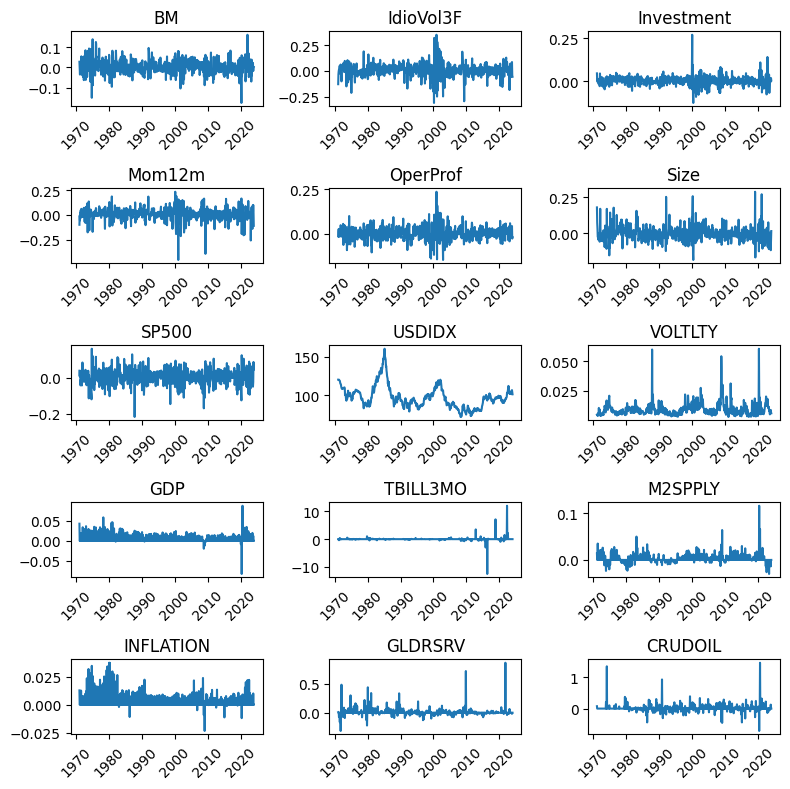

In [10]:
# quick visualization of processed data
rows = 5
cols = 3

fig, axs = plt.subplots(rows, cols, figsize=(8,8))
for r in range(rows):
    for c in range(cols):
        axs[r,c].plot(df1.iloc[:, cols*r+c])
        axs[r,c].set_title(df1.columns[cols*r+c])
        axs[r,c].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

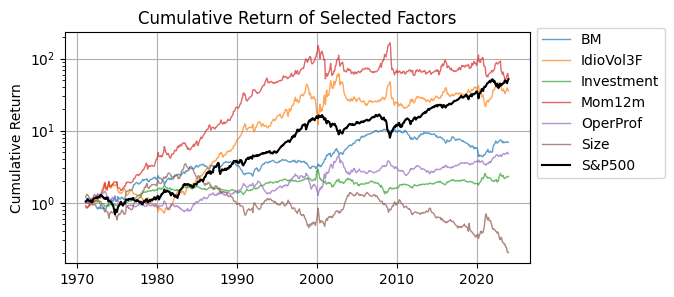

In [11]:
# plot relative cumulative returns for the factors compared to the index
# just for sanity check
plt.subplots()
plt.plot((1 + df1.iloc[:, :6]).cumprod(),
         alpha=0.7,
         linewidth=1.0,
         label=df1.columns[:6])
plt.plot((1 + df1.loc[:,'SP500']).cumprod(),
         c='black',
         label='S&P500')
plt.ylabel('Relative Performance (Log Scale)')
plt.legend(bbox_to_anchor=(1, 1.05))
plt.ylabel('Cumulative Return')
plt.title('Cumulative Return of Selected Factors')
plt.yscale('log')
plt.grid()
plt.show()

### 1.3. Evaluation of Mutual Information

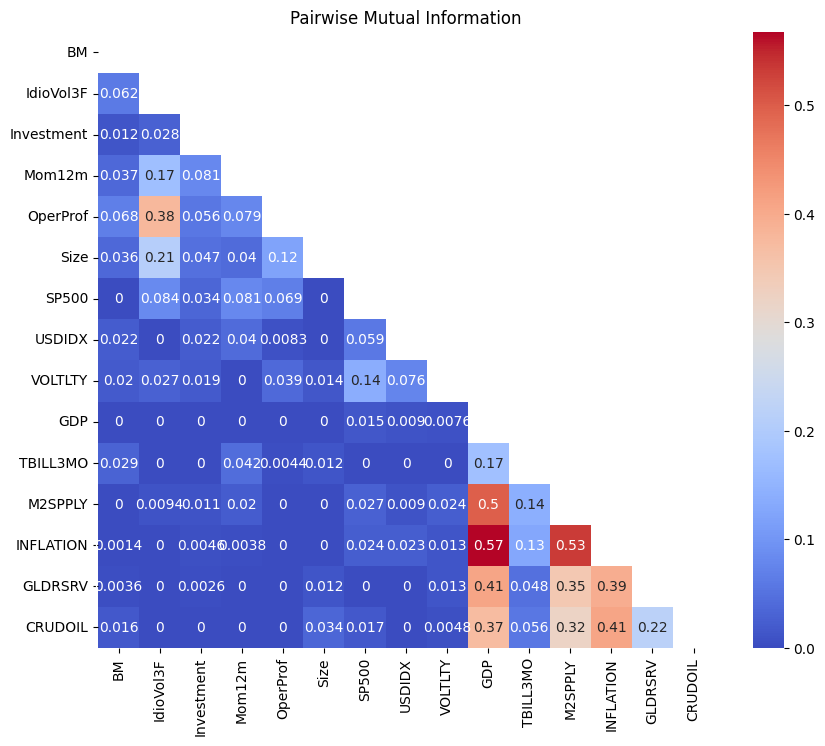

In [12]:
# Code snippets below were modified from:
# https://www.geeksforgeeks.org/data-visualization/calculating-pairwise-mutual-information-in-pandas/

from sklearn.feature_selection import mutual_info_regression
from seaborn import heatmap

# Initialize a matrix to store mutual information
dependent_vars = df1.columns
independent_vars = dependent_vars
mutual_info_matrix = np.zeros((len(independent_vars), len(dependent_vars)))

# Calculate mutual information for each independent-dependent variable pair
for i, var1 in enumerate(independent_vars):
    for j, var2 in enumerate(dependent_vars):
        X = df1[[var1]]
        y = df1[var2]
        mutual_info = mutual_info_regression(X, y)
        mutual_info_matrix[i, j] = mutual_info[0]  # Store the mutual info scalar

# Convert the matrix to a DataFrame for easier viewing
mutual_info_df = pd.DataFrame(mutual_info_matrix, index=independent_vars, columns=dependent_vars)

# Display the mutual information DataFrame
# print(mutual_info_df)

# visualize MI dataframe as a heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(mutual_info_df, dtype=bool))
heatmap(mutual_info_df, annot=True, cmap='coolwarm', square=True, mask=mask)
plt.title('Pairwise Mutual Information')
plt.show()

It's interesting that the MI between many of the macroeconomic indicators and the factor returns are 0. 

### 1.4. Data Discretization with Trend Scanning

Instead of worrying about whether the continuous data are stationary or not, since the DYNOTEARS model in Causalnex can only handle discrete data, maybe it's better to just discretize our data before BN model learning. Here, I just wanted to try out a different way of discretizing data (an alternative way would be to use HMM like in GWP3 in the RM course).

This particular method, called **trend scanning**, was taken from Lopez de Prado's book (Machine Learning for Asset Managers, pp. 67-72). The Python implementation below was modified from code adaptations by Endre Moen (https://github.com/emoen/Machine-Learning-for-Asset-Managers). Basically, this method uses the t-statistics from rolling linear regressions to determine if a stretch of price or index level series is part of an up-trend or a down-trend. I've modified the code so that it can label sideways price movement too (i.e., no trend), so we'll end up with 3 labels or "states". For this, we need to convert the returns data back to price, or at least, cumulative returns, so that the change in trends can be identified.

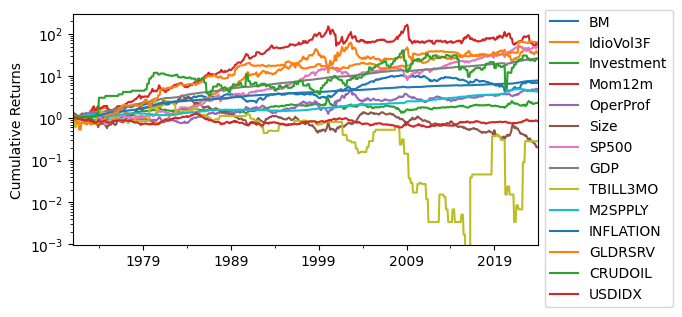

In [13]:
# change stationary data into cumulative returns
df2 = df1.copy().drop(['USDIDX', 'VOLTLTY'], axis=1)
df2 = (1 + df2).cumprod()
df2['USDIDX'] = (1 + df1['USDIDX'].pct_change()).cumprod()
# df2['VOLTLTY'] = (1 + df1['VOLTLTY'].pct_change()).cumprod()

df2.plot()
plt.yscale('log')
plt.ylabel('Cumulative Returns')
plt.legend(bbox_to_anchor=(1,1.05))
plt.show()

In [14]:
import statsmodels.api as sm

def tValLinR(close: np.ndarray) -> float:
    """
    Compute the t-statistic of the slope coefficient from an OLS regression
    of `close` values against time.

    Parameters
    ----------
    close : np.ndarray
        Array of values (e.g., prices) in the window.

    Returns
    -------
    float
        t-statistic of the slope coefficient.
    """
    if close.ndim > 1:
        close = close.ravel()

    n = close.shape[0]
    x = np.ones((n, 2))
    x[:, 1] = np.arange(n)
    ols = sm.OLS(close, x).fit()
    return float(ols.tvalues[1])


def getBinsFromTrend(
    molecule: pd.Index,
    close: pd.Series,
    span: tuple[int, int, int], # = (3, 20, 1),
    tval_clip: float = 30.0,
) -> pd.DataFrame:
    """
    Apply the trend-scanning method to generate labels.

    Parameters
    ----------
    molecule : pd.Index
        Subset of indices from `close` to evaluate.
    close : pd.Series
        Price or time series data.
    span : tuple[int, int, int], optional
        Range of window sizes to test (start, stop, step).
        Example: (3, 10, 1) tests windows of size 3..9.
    tval_clip : float, optional
        Maximum absolute value to clip t-statistics at.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns:
        - t1: Start time of chosen trend window
        - tVal: t-statistic of chosen window
        - bin: Sign of tVal (+1, -1, or 0)
        - windowSize: Length of chosen window
    """
    hrzns = range(*span)
    minWindow, maxWindow = span[0], span[1] - 1

    out = pd.DataFrame(index=molecule, columns=["t1", "tVal", "bin", "windowSize"])

    for idx in molecule:
        pos = close.index.get_loc(idx)
        if pos < maxWindow:
            continue  # not enough history

        df_tval = pd.Series(dtype="float64")
        for hrzn in hrzns:
            start_pos = pos - hrzn + 1
            if start_pos < 0:
                continue
            dt1 = close.index[start_pos]
            df1 = close.iloc[start_pos : pos + 1]
            df_tval.loc[dt1] = tValLinR(df1.values)

        # Replace problematic values and choose window with strongest |t|
        df_tval = df_tval.replace([-np.inf, np.inf, np.nan], 0.0)
        chosen_start = df_tval.abs().idxmax()
        chosen_tval = df_tval.loc[chosen_start]
        chosen_window = df_tval.abs().values.argmax() + minWindow

        # out.loc[idx, ["t1", "tVal", "bin", "windowSize"]] = (
        #     chosen_start,
        #     chosen_tval,
        #     np.sign(chosen_tval),
        #     chosen_window,
        # )
        
        out.loc[idx, ["t1", "tVal", "windowSize"]] = (
            chosen_start,
            chosen_tval,
            chosen_window,
        )

    out["t1"] = pd.to_datetime(out["t1"])
    out["tVal"] = out["tVal"].astype(float).clip(-tval_clip, tval_clip)
    out["bin"] = pd.qcut(out["tVal"], q=3, labels=False) # modified to include 3 labels / trend states
    # out["bin"] = pd.to_numeric(out["bin"], downcast="signed")

    return out.dropna(subset=["bin"])

In [15]:
idx_range_from = 3
idx_range_to = 10

# now execute trend scanning & loop over all variables
trnd_lbl_df = pd.DataFrame(index=df2.index, columns=df2.columns)

for c in range(len(df2.columns)):

    df3 = pd.Series(index = df2.index, data = df2.iloc[:, c].values)
    df4 = getBinsFromTrend(df3.index, df3, [idx_range_from,idx_range_to,1], 20)
    trnd_lbl_df[df2.columns[c]] = df4['bin']

trnd_lbl_df = trnd_lbl_df.dropna()
trnd_lbl_df.shape

(627, 14)

In [16]:
df2.columns

Index(['BM', 'IdioVol3F', 'Investment', 'Mom12m', 'OperProf', 'Size', 'SP500',
       'GDP', 'TBILL3MO', 'M2SPPLY', 'INFLATION', 'GLDRSRV', 'CRUDOIL',
       'USDIDX'],
      dtype='object')

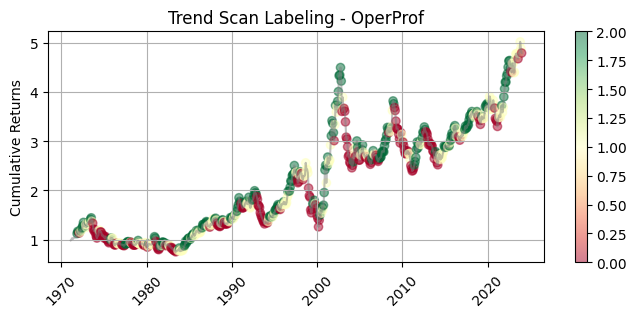

In [17]:
# visualize one of the variables
plt.subplots(figsize=(8,3))
plt.plot(df2.iloc[:,4], color='grey', alpha=0.5)
plt.scatter(trnd_lbl_df.index,
            df2.loc[trnd_lbl_df.index, df2.columns[4]],
            c=trnd_lbl_df.iloc[:,4].values,
            cmap='RdYlGn', alpha=0.5)
plt.colorbar()
plt.grid()
plt.xticks(rotation=45)
plt.ylabel('Cumulative Returns')
plt.title(f'Trend Scan Labeling - {trnd_lbl_df.columns[4]}')
plt.show()

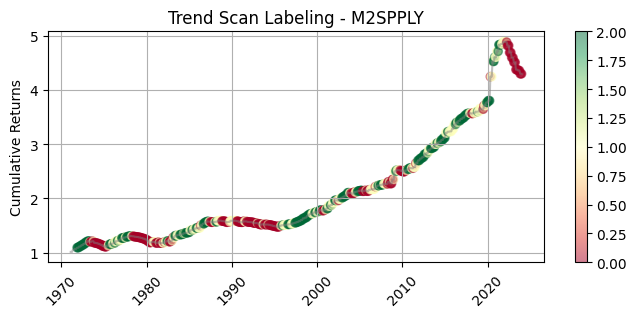

In [18]:
# visualize one of the variables
plt.subplots(figsize=(8,3))
plt.plot(df2.iloc[:,9], color='grey', alpha=0.5)
plt.scatter(trnd_lbl_df.index,
            df2.loc[trnd_lbl_df.index, df2.columns[9]],
            c=trnd_lbl_df.iloc[:,9].values,
            cmap='RdYlGn', alpha=0.5)
plt.colorbar()
plt.grid()
plt.xticks(rotation=45)
plt.ylabel('Cumulative Returns')
plt.title(f'Trend Scan Labeling - {trnd_lbl_df.columns[9]}')
plt.show()

### 1.5. Train-Test Dataset Split

In [19]:
# split data into training & testing sets (80:20 split)

train_data = trnd_lbl_df.iloc[: int(trnd_lbl_df.shape[0] * 0.80)]
test_data = trnd_lbl_df.iloc[int(0.80 * trnd_lbl_df.shape[0]) : int(trnd_lbl_df.shape[0])]

print("Training Set Size: ", train_data.shape)
print("Start of Training Period: ", train_data.index[0])
print("End of Training Period: ", train_data.index[-1])

print("\nTesting Set Size: ", test_data.shape)
print("Start of Testing Period: ", test_data.index[0])
print("End of Testing Period: ", test_data.index[-1])

Training Set Size:  (501, 14)
Start of Training Period:  1971-10-31 00:00:00
End of Training Period:  2013-06-30 00:00:00

Testing Set Size:  (126, 14)
Start of Testing Period:  2013-07-31 00:00:00
End of Testing Period:  2023-12-31 00:00:00


## Section 2 - Bayesian Network

### 2.1. Dynamic BN (DYNOTEARS) Structure Learning

In [20]:
# copy dataframe (just in case) & reset index
trnd_lbl_df1 = train_data.copy()
trnd_lbl_df1 = trnd_lbl_df1.reset_index(drop=True) # dynotears requires integer index

# causal structure learning w/ DYNOTEARS
from causalnex.structure.dynotears import from_pandas_dynamic

csl_grph = from_pandas_dynamic(
    trnd_lbl_df1,
    1,
    lambda_w=0.1,
    lambda_a=0.1,
    w_threshold=0.05,  # keep threshold value low to keep weak links
)

# copy the DAG (just in case) & inspect the edges
grph = deepcopy(csl_grph)
for e in grph.edges:
    print(e)

('BM_lag0', 'Size_lag0')
('BM_lag1', 'BM_lag0')
('IdioVol3F_lag0', 'OperProf_lag0')
('IdioVol3F_lag1', 'IdioVol3F_lag0')
('IdioVol3F_lag1', 'GDP_lag0')
('Investment_lag0', 'SP500_lag0')
('Investment_lag1', 'Investment_lag0')
('Investment_lag1', 'Size_lag0')
('Mom12m_lag0', 'IdioVol3F_lag0')
('Mom12m_lag1', 'Investment_lag0')
('Mom12m_lag1', 'Mom12m_lag0')
('OperProf_lag1', 'IdioVol3F_lag0')
('OperProf_lag1', 'OperProf_lag0')
('OperProf_lag1', 'INFLATION_lag0')
('Size_lag1', 'Size_lag0')
('SP500_lag1', 'Size_lag0')
('SP500_lag1', 'SP500_lag0')
('GDP_lag0', 'Mom12m_lag0')
('GDP_lag1', 'GDP_lag0')
('TBILL3MO_lag0', 'GDP_lag0')
('TBILL3MO_lag0', 'INFLATION_lag0')
('TBILL3MO_lag1', 'TBILL3MO_lag0')
('M2SPPLY_lag1', 'GDP_lag0')
('M2SPPLY_lag1', 'M2SPPLY_lag0')
('INFLATION_lag0', 'GDP_lag0')
('INFLATION_lag1', 'INFLATION_lag0')
('GLDRSRV_lag1', 'GLDRSRV_lag0')
('CRUDOIL_lag1', 'Investment_lag0')
('CRUDOIL_lag1', 'INFLATION_lag0')
('CRUDOIL_lag1', 'CRUDOIL_lag0')
('USDIDX_lag1', 'BM_lag0')
('U

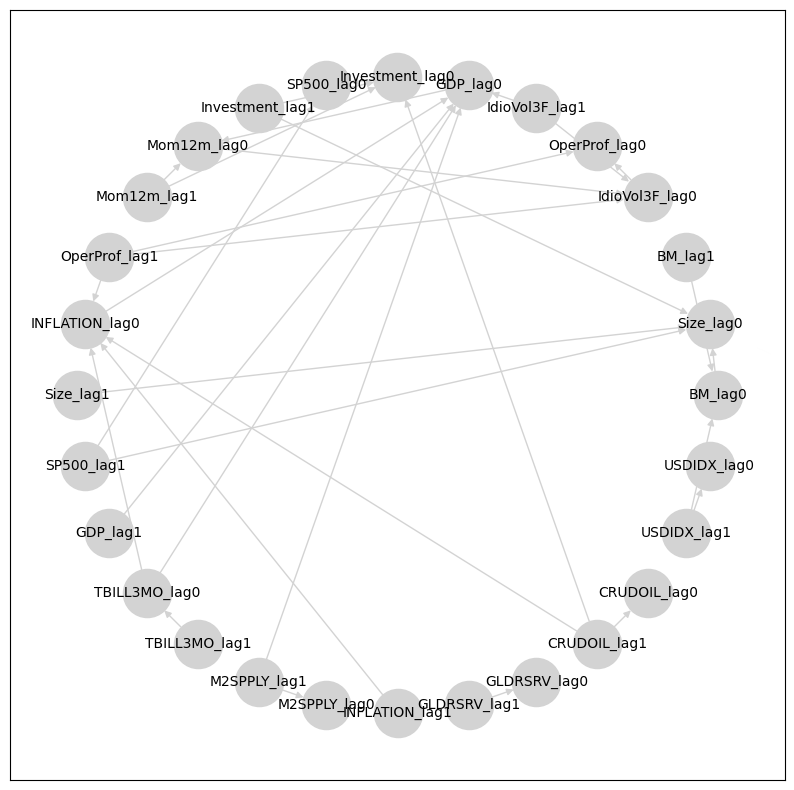

In [21]:
# visualize the estimated DAG structure
import networkx as nx
plt.subplots(figsize=(10,10))
G = nx.DiGraph()
G.add_edges_from(grph.edges)
pos = nx.circular_layout(G)
nx.draw_networkx(G, pos,
                 node_color='lightgrey',
                 node_size=1200,
                 edge_color='lightgrey',
                 font_size=10,
                 font_weight=14)
plt.show()

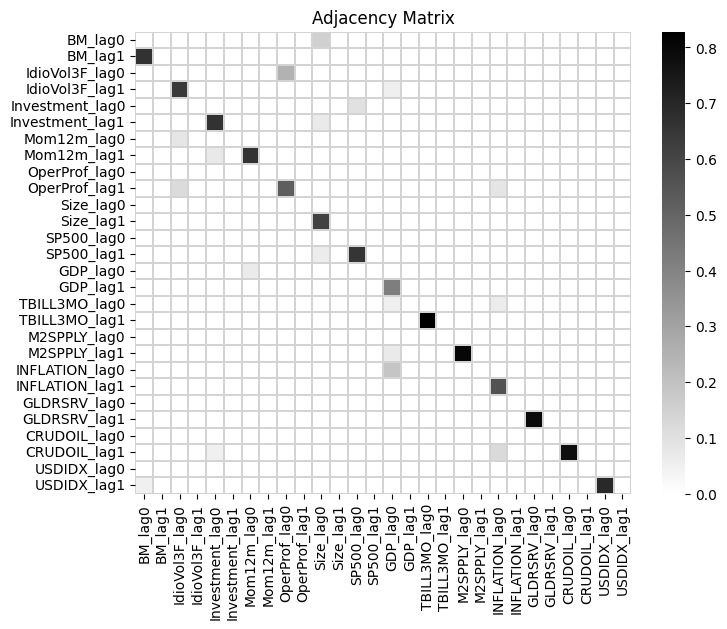

In [22]:
# visualize adjacency matrix
adj_mtx = nx.adjacency_matrix(grph)
adj_mtx_df = pd.DataFrame(data = adj_mtx.toarray(),
                          columns = grph.nodes,
                          index = grph.nodes)
plt.subplots(figsize=(8,6))
heatmap(adj_mtx_df,
        linecolor='lightgrey',
        linewidths=0.01,
        cmap='binary')
plt.title('Adjacency Matrix')
plt.show()

### 2.2. Parameter Learning

In [23]:
# create a new BN to be parameterized
from causalnex.network import BayesianNetwork
bn = BayesianNetwork(grph.get_largest_subgraph())

In [24]:
# copy the training dataset
temp_df = train_data.copy()
temp_df.columns = [f'{i}_lag0' for i in trnd_lbl_df1.columns]

# generate lag1 data
for j in temp_df.columns:
    temp_df[f'{j[:-1]}1'] = temp_df[j].shift(-1).fillna(0)

# select columns that are present as nodes in the estimated DAG above
slctd_cols = []
for e in grph.edges:
    for f in range(2):
        if e[f] not in slctd_cols:
            slctd_cols.append(e[f])
        else:
            continue

# fit parameters to the BN
bn = bn.fit_node_states(temp_df)
bn = bn.fit_cpds(temp_df,
                 method = 'BayesianEstimator',
                 bayes_prior = 'K2')

In [25]:
# select columns that are present as nodes in the fitted BN
slctd_cols = []
for e in bn.edges:
    for f in range(2):
        if e[f] not in slctd_cols:
            slctd_cols.append(e[f])
        else:
            continue

# inspect CPTs (& store in a dict for later, just in case)
CPT = {}
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
for i in slctd_cols:
    CPT[i] = bn.cpds[i]
    print(bn.cpds[i])
    print('')

BM_lag1           0.0                           1.0                      \
USDIDX_lag1       0.0       1.0       2.0       0.0       1.0       2.0   
BM_lag0                                                                   
0.0          0.686567  0.702128  0.634146  0.196721  0.250000  0.241379   
1.0          0.208955  0.255319  0.292683  0.590164  0.383333  0.534483   
2.0          0.104478  0.042553  0.073171  0.213115  0.366667  0.224138   

BM_lag1           2.0                      
USDIDX_lag1       0.0       1.0       2.0  
BM_lag0                                    
0.0          0.076923  0.034483  0.028169  
1.0          0.215385  0.275862  0.295775  
2.0          0.707692  0.689655  0.676056  

BM_lag0             0.0                                               \
Investment_lag1     0.0                                                
SP500_lag1          0.0                  1.0                     2.0   
Size_lag1           0.0       1.0   2.0  0.0       1.0    2.0    0.0

### 2.3. An Inference Example

In [26]:
from causalnex.inference import InferenceEngine

In [27]:
# copy the testing dataset & select variables present in the BN
test_data1 = test_data.copy()
test_data1.columns = [f"{k}_lag0" for k in test_data.columns]
slctd = []
for k in test_data1.columns:
    if k in slctd_cols:
        slctd.append(k)
test_data1 = test_data1.loc[:,slctd]

In [28]:
test_data1.columns

Index(['BM_lag0', 'IdioVol3F_lag0', 'Investment_lag0', 'Mom12m_lag0',
       'OperProf_lag0', 'Size_lag0', 'SP500_lag0', 'GDP_lag0', 'TBILL3MO_lag0',
       'M2SPPLY_lag0', 'INFLATION_lag0', 'CRUDOIL_lag0', 'USDIDX_lag0'],
      dtype='object')

In [29]:
test_data1.head()

,BM_lag0,IdioVol3F_lag0,Investment_lag0,Mom12m_lag0,OperProf_lag0,Size_lag0,SP500_lag0,GDP_lag0,TBILL3MO_lag0,M2SPPLY_lag0,INFLATION_lag0,CRUDOIL_lag0,USDIDX_lag0
2013-07-31,1.0,0.0,1.0,1.0,0.0,2.0,2.0,0.0,1.0,2.0,0.0,1.0,1.0
2013-08-31,1.0,0.0,1.0,0.0,0.0,2.0,2.0,0.0,0.0,2.0,0.0,1.0,1.0
2013-09-30,0.0,0.0,2.0,0.0,0.0,2.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0
2013-10-31,0.0,0.0,1.0,0.0,0.0,2.0,2.0,0.0,0.0,1.0,0.0,1.0,0.0
2013-11-30,1.0,1.0,0.0,1.0,2.0,1.0,2.0,2.0,0.0,1.0,1.0,0.0,1.0


In [30]:
# make inferences based on the evidence
ie = InferenceEngine(bn)

# Example: based on evidence on the 1st test data time point
evdnc = test_data1.iloc[0, -6:].to_dict()
mrgnls = ie.query(evdnc) # this is a dictionary the inference engine produces

# print the marginal probabilities given the evidence of the 1st time point
for m in mrgnls.keys():
    print(m)
    for n, x in enumerate(mrgnls[m].values()):
        print(f'{n}\t{x: .3f}')


BM_lag0
0	 0.295
1	 0.329
2	 0.376
Size_lag0
0	 0.316
1	 0.322
2	 0.362
BM_lag1
0	 0.292
1	 0.339
2	 0.369
IdioVol3F_lag0
0	 0.326
1	 0.329
2	 0.345
OperProf_lag0
0	 0.378
1	 0.316
2	 0.306
IdioVol3F_lag1
0	 0.303
1	 0.339
2	 0.358
GDP_lag0
0	 1.000
1	 0.000
2	 0.000
Investment_lag0
0	 0.325
1	 0.337
2	 0.338
SP500_lag0
0	 0.350
1	 0.340
2	 0.310
Investment_lag1
0	 0.325
1	 0.333
2	 0.341
Mom12m_lag0
0	 0.350
1	 0.307
2	 0.344
Mom12m_lag1
0	 0.317
1	 0.317
2	 0.365
OperProf_lag1
0	 0.399
1	 0.311
2	 0.291
INFLATION_lag0
0	 1.000
1	 0.000
2	 0.000
Size_lag1
0	 0.317
1	 0.315
2	 0.367
SP500_lag1
0	 0.351
1	 0.329
2	 0.319
GDP_lag1
0	 0.405
1	 0.357
2	 0.238
TBILL3MO_lag0
0	 0.000
1	 1.000
2	 0.000
TBILL3MO_lag1
0	 0.144
1	 0.742
2	 0.114
M2SPPLY_lag1
0	 0.021
1	 0.188
2	 0.791
M2SPPLY_lag0
0	 0.000
1	 0.000
2	 1.000
INFLATION_lag1
0	 0.598
1	 0.208
2	 0.194
CRUDOIL_lag1
0	 0.238
1	 0.577
2	 0.185
CRUDOIL_lag0
0	 0.000
1	 1.000
2	 0.000
USDIDX_lag1
0	 0.214
1	 0.566
2	 0.220
USDIDX_lag0
0

The (perhaps questionable) assumption here is that, we only observe the macroeconomic indicator data states before the factor returns states (which we assume to be unobserved at the current time step).

In [31]:
# extract the probabilities for the factors from the inference above & store in a dataframe
fctr_mrgnls = pd.DataFrame(index = [0, 1, 2])
for k in test_data1.columns[:6]:
    fctr_mrgnls[k] = mrgnls[k]
fctr_mrgnls.columns = [k[:-5] for k in fctr_mrgnls.columns] # drop 'lag_0' from col names
fctr_mrgnls

,BM,IdioVol3F,Investment,Mom12m,OperProf,Size
0,0.295325,0.326177,0.324906,0.349558,0.378301,0.316268
1,0.328989,0.329166,0.336890,0.306896,0.315688,0.322109
2,0.375686,0.344657,0.338204,0.343546,0.306010,0.361623


Now, the task is to convert the probabilities above into expected returns & volatility for utility optimization later on.

In [32]:
# first, we calculate the mean & std of returns for e/a tertile for e/a factor (from training data)
ret_qtl = pd.DataFrame(index = [0, 1, 2])
std_qtl = pd.DataFrame(index = [0, 1, 2])
temp0 = pd.DataFrame()

for v in df1.columns[:6]:
    temp0['ret'] = df1.loc[trnd_lbl_df.index,v]
    temp0['qtl'] = trnd_lbl_df.loc[:,v].values
    temp1 = temp0.groupby('qtl')['ret'].agg(['mean', 'std'])
    ret_qtl[v] = temp1['mean']
    std_qtl[v] = temp1['std']

# state (trend)-dependent mean returns
ret_qtl

,BM,IdioVol3F,Investment,Mom12m,OperProf,Size
0,-0.014727,-0.024880,-0.011348,-0.022516,-0.017456,-0.026749
1,0.005404,0.010042,0.003802,0.009360,0.003211,-0.003842
2,0.020546,0.039185,0.012560,0.039674,0.023661,0.026575


This makes sense probably, since the average returns of a down-trend (state label = 0) is negative, whereas that of an up-trend (state = 2) is positive.

In [33]:
# state (trend)-dependent std deviation of returns
std_qtl

,BM,IdioVol3F,Investment,Mom12m,OperProf,Size
0,0.028471,0.063866,0.025015,0.075536,0.033029,0.035416
1,0.040341,0.075810,0.031993,0.061051,0.037054,0.057319
2,0.027492,0.043974,0.022347,0.044370,0.035066,0.050729


What now? Shall we take the state with the largest probability & use that as an estimate of expected return & volatility? That's one way, I suppose. Afterwards, we can use these for weight optimizations in a separate utility module & eventually implement it on a rolling basis.

In [34]:
mu = []
sigma = []

for v in df1.columns[:6]:
    state = fctr_mrgnls.loc[:,v].idxmax()
    # print(state)
    mu.append(ret_qtl.loc[state,v])
    sigma.append(std_qtl.loc[state,v])

print(f'Expected Factor Returns')
for j in range(6):
    print(f"{df1.columns[j]}: {mu[j]: .3f}")
print(f'\nExpected Factor Volatility')
for j in range(6):
    print(f"{df1.columns[j]}: {sigma[j]: .3f}")

Expected Factor Returns
BM:  0.021
IdioVol3F:  0.039
Investment:  0.013
Mom12m: -0.023
OperProf: -0.017
Size:  0.027

Expected Factor Volatility
BM:  0.027
IdioVol3F:  0.044
Investment:  0.022
Mom12m:  0.076
OperProf:  0.033
Size:  0.051
